## Ejemplo Práctico

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Cargar datos
data = load_breast_cancer()
X, y = data.data, data.target

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo
model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)

# Predecir y evaluar
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Precisión: {accuracy:.4f}")
print("\nInforme de clasificación:")
print(report)

Precisión: 0.9561

Informe de clasificación:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Live Coding

Vamos a entrenar un modelo de clasificación con Gradient Boosting utilizando el dataset de cáncer de mama. Se mostrará cómo ajustar hiperparámetros e interpretar el resultado.

1. Cargar dataset load_breast_cancer() desde Scikit-learn.



In [2]:
!pip install ucimlrepo

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from ucimlrepo import fetch_ucirepo
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [4]:
# 1) Cargar dataset UCI (Original)
data = fetch_ucirepo(id=15)

| Variable                        | Qué representa                              | Intuición clínica                                               |
| ------------------------------- | ------------------------------------------- | --------------------------------------------------------------- |
| **Clump_thickness**             | Espesor del conglomerado celular            | Tumores malignos tienden a formar masas más gruesas y compactas |
| **Uniformity_of_cell_size**     | Uniformidad en el tamaño de las células     | En tumores malignos las células varían mucho en tamaño          |
| **Uniformity_of_cell_shape**    | Uniformidad en la forma de las células      | Las células cancerosas suelen tener formas irregulares          |
| **Marginal_adhesion**           | Adhesión entre células en los bordes        | En cáncer, las células pierden adhesión normal                  |
| **Single_epithelial_cell_size** | Tamaño de células epiteliales individuales  | Aumento anormal puede indicar malignidad                        |
| **Bare_nuclei**                 | Núcleos “desnudos” (sin citoplasma visible) | Indicador fuerte de células anormales                           |
| **Bland_chromatin**             | Apariencia de la cromatina nuclear          | Cromatina irregular o granular es típica en malignidad          |
| **Normal_nucleoli**             | Presencia y tamaño de nucleolos             | Nucleolos prominentes son comunes en células cancerosas         |
| **Mitoses**                     | Cantidad de divisiones celulares observadas | Alta tasa mitótica → crecimiento agresivo                       |

In [5]:
X = data.data.features.copy()
y = data.data.targets.copy()

In [6]:
y.value_counts()

,count
Class,
2,458
4,241


* 2 → (Benigno)
* 4 → (Maligno)

In [7]:
X.isnull().sum()

,0
Clump_thickness,0
Uniformity_of_cell_size,0
Uniformity_of_cell_shape,0
Marginal_adhesion,0
Single_epithelial_cell_size,0
Bare_nuclei,16
Bland_chromatin,0
Normal_nucleoli,0
Mitoses,0


2. Separar en train/test (80/20).


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
print("\nTrain:", X_train.shape, " Test:", X_test.shape)


Train: (559, 9)  Test: (140, 9)


3. Crear y entrenar un modelo con GradientBoostingClassifier.


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(random_state=42))
])

In [11]:
pipeline.fit(X_train, y_train.values.ravel())

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model', GradientBoostingClassifier(random_state=42))])

4. Evaluar con accuracy_score y classification_report.


In [13]:
from sklearn.metrics import f1_score

y_pred = pipeline.predict(X_test)

print("\n=== Baseline (sin tuning) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
# F1 para la clase positiva (Maligno=4): evento de interés
print("F1 (Maligno=4):", f1_score(y_test, y_pred, pos_label=4, average="binary"))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n",
      classification_report(y_test, y_pred, labels=[2,4], target_names=["Benigno", "Maligno"]))


=== Baseline (sin tuning) ===
Accuracy: 0.9571428571428572
F1 (Maligno=4): 0.9375

Matriz de confusión:
 [[89  3]
 [ 3 45]]

Classification report:
               precision    recall  f1-score   support

     Benigno       0.97      0.97      0.97        92
     Maligno       0.94      0.94      0.94        48

    accuracy                           0.96       140
   macro avg       0.95      0.95      0.95       140
weighted avg       0.96      0.96      0.96       140



5. Ajustar hiperparámetros: n_estimators, learning_rate, max_depth.


In [16]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, confusion_matrix, classification_report, make_scorer

# Cantidad de pasos (n_estimators)
# Tamaño de cada paso (learning_rate)
# Complejidad de cada paso (max_depth)
param_grid = {
    "model__n_estimators": [100, 200, 300], # n_estimators = “cuántos pasos de mejora” (cuántas “correcciones” hace el modelo.)
    "model__learning_rate": [0.05, 0.1, 0.2], # qué tan grande es cada corrección.
    # Bajo (0.05): correcciones pequeñas y cuidadosas → suele generalizar mejor, pero necesita más árboles.
    # Medio (0.1): equilibrio típico.
    # Alto (0.2): aprende más rápido, pero puede pasarse de largo y sobreajustar.
    "model__max_depth": [2, 3, 4] # la complejidad de cada árbol (qué tan “profundas” son las reglas).
    # depth 2: reglas simples, muy generales
    # depth 3: un poco más flexible
    # depth 4: más complejidad → puede capturar patrones finos… pero también ruido
}

# Voy a evaluar el modelo en 5 particiones, manteniendo la proporción de benignos/malignos en cada una, y mezclando los datos para que la evaluación sea justa y repetible.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define a custom F1 scorer con pos_label=4
f1_scorer = make_scorer(f1_score, pos_label=4, average='binary') # pos_label=4 F1 que se obtenga va a ser el F1 centrado en detectar la clase 4

grid = GridSearchCV(
    estimator=pipeline, # Use the pipeline as the estimator
    param_grid=param_grid,
    scoring=f1_scorer,  # F1 enfocado en Maligno (label=4)
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train.values.ravel())

print("\n=== GridSearchCV ===")
print("Mejores params:", grid.best_params_)
print("Mejor F1 (CV):", grid.best_score_)

best_gb = grid.best_estimator_

# Evaluación final en test
y_pred_best = best_gb.predict(X_test)

print("\n=== Test con mejores hiperparámetros ===")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("F1:", f1_score(y_test, y_pred_best, pos_label=4, average='binary'))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_best))
print("\nClassification report:\n",
      classification_report(
          y_test, y_pred_best,
          labels=[2, 4],
          target_names=["Benigno", "Maligno"]
      ))
print("F1 macro:", f1_score(y_test, y_pred_best, labels=[2,4], average="macro"))
print("F1 weighted:", f1_score(y_test, y_pred_best, labels=[2,4], average="weighted"))


=== GridSearchCV ===
Mejores params: {'model__learning_rate': 0.2, 'model__max_depth': 4, 'model__n_estimators': 100}
Mejor F1 (CV): 0.9593963289598719

=== Test con mejores hiperparámetros ===
Accuracy: 0.95
F1: 0.9278350515463918

Matriz de confusión:
 [[88  4]
 [ 3 45]]

Classification report:
               precision    recall  f1-score   support

     Benigno       0.97      0.96      0.96        92
     Maligno       0.92      0.94      0.93        48

    accuracy                           0.95       140
   macro avg       0.94      0.95      0.94       140
weighted avg       0.95      0.95      0.95       140

F1 macro: 0.9447918427130866
F1 weighted: 0.9501211199369051


In [18]:
grid.cv_results_["mean_test_score"]

array([0.94596086, 0.95640581, 0.95380413, 0.93840997, 0.94340606,
       0.95134929, 0.93320493, 0.95180675, 0.95141441, 0.94882298,
       0.95139906, 0.95633044, 0.93833018, 0.95434255, 0.95160844,
       0.94907264, 0.9486803 , 0.95407264, 0.95380413, 0.95134343,
       0.95134343, 0.95386624, 0.95660308, 0.95386624, 0.95939633,
       0.95921181, 0.95921181])

In [19]:
grid.cv_results_["std_test_score"]

array([0.01143363, 0.00987608, 0.00647221, 0.01370916, 0.00957246,
       0.0084095 , 0.01573868, 0.01761189, 0.01409917, 0.00724844,
       0.00504796, 0.00590774, 0.00809998, 0.01206409, 0.01178245,
       0.01701753, 0.01326871, 0.01220122, 0.00647221, 0.00988849,
       0.00988849, 0.00599875, 0.009976  , 0.00599875, 0.00854039,
       0.01151117, 0.01151117])

6. Visualizar feature_importances_.


* Es el peso o relevancia que el modelo le da a cada variable para hacer sus predicciones

In [20]:
import matplotlib.pyplot as plt

# va a dentro del pipeline y sacar las importancias del paso model
importances = best_gb.named_steps['model'].feature_importances_

imp_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop 10 variables por importancia:\n", imp_df.head(10))


Top 10 variables por importancia:
                        feature  importance
1      Uniformity_of_cell_size    0.751884
5                  Bare_nuclei    0.122890
0              Clump_thickness    0.034764
2     Uniformity_of_cell_shape    0.030969
7              Normal_nucleoli    0.022616
6              Bland_chromatin    0.014993
3            Marginal_adhesion    0.014558
8                      Mitoses    0.004770
4  Single_epithelial_cell_size    0.002557


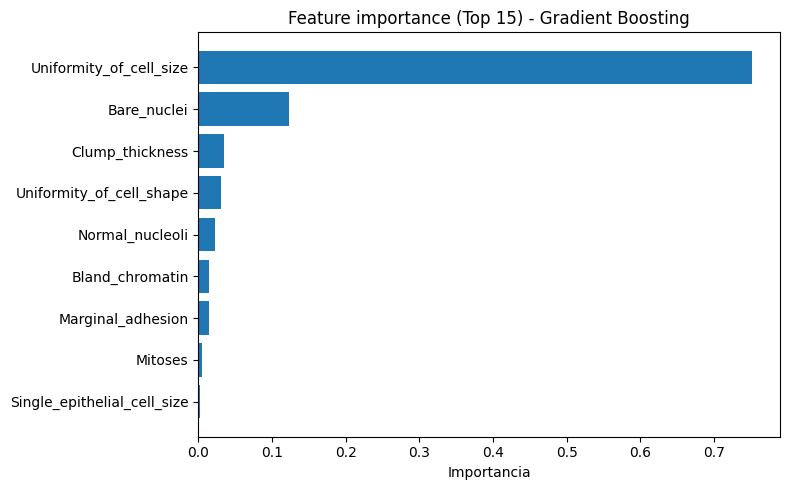

In [21]:
plt.figure(figsize=(8,5))
plt.barh(imp_df["feature"].head(15)[::-1], imp_df["importance"].head(15)[::-1])
plt.title("Feature importance (Top 15) - Gradient Boosting")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

| Variable                        | Qué representa                              | Intuición clínica                                               |
| ------------------------------- | ------------------------------------------- | --------------------------------------------------------------- |
| **Clump_thickness**             | Espesor del conglomerado celular            | Tumores malignos tienden a formar masas más gruesas y compactas |
| **Uniformity_of_cell_size**     | Uniformidad en el tamaño de las células     | En tumores malignos las células varían mucho en tamaño          |
| **Uniformity_of_cell_shape**    | Uniformidad en la forma de las células      | Las células cancerosas suelen tener formas irregulares          |
| **Marginal_adhesion**           | Adhesión entre células en los bordes        | En cáncer, las células pierden adhesión normal                  |
| **Single_epithelial_cell_size** | Tamaño de células epiteliales individuales  | Aumento anormal puede indicar malignidad                        |
| **Bare_nuclei**                 | Núcleos “desnudos” (sin citoplasma visible) | Indicador fuerte de células anormales                           |
| **Bland_chromatin**             | Apariencia de la cromatina nuclear          | Cromatina irregular o granular es típica en malignidad          |
| **Normal_nucleoli**             | Presencia y tamaño de nucleolos             | Nucleolos prominentes son comunes en células cancerosas         |
| **Mitoses**                     | Cantidad de divisiones celulares observadas | Alta tasa mitótica → crecimiento agresivo                       |

* El 75% del “poder de decisión” del modelo está concentrado en UNA sola variable.
* Aunque entrenamos el modelo con muchas variables, el algoritmo descubrió que solo una o dos son realmente determinantes para clasificar maligno vs benigno.

7. Realizar validación cruzada con cross_val_score.


In [22]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scorer = make_scorer(f1_score, pos_label=4, average="binary")

scores = cross_val_score(best_gb, X_train, y_train.values.ravel(), cv=cv, scoring=f1_scorer, n_jobs=-1)

print("F1 (Maligno=4) por fold:", scores)
print("Promedio F1:", scores.mean())
print("Desv. estándar:", scores.std())

F1 (Maligno=4) por fold: [0.97368421 0.96103896 0.95121951 0.95       0.96103896]
Promedio F1: 0.9593963289598719
Desv. estándar: 0.008540390743726636


8. Discutir limitaciones y buenas prácticas.

**Buenas prácticas:**

Limitaciones del modelo
1. Tamaño y representatividad del dataset

    Aunque el rendimiento es alto, el dataset no necesariamente representa todos los escenarios reales.
    Si aparecen pacientes con características fuera del rango observado, el modelo puede fallar.

    Los modelos no “entienden”, interpolan lo que ya vieron.

2. Riesgo de sobreajuste leve

    El F1 en CV fue 0.959 y en test 0.928.
    La diferencia es pequeña, pero existe.

    Eso indica que el modelo generaliza bien, pero no perfectamente.
    Siempre existe cierto optimismo en validación cruzada.

3. Interpretabilidad limitada

    Aunque podemos extraer feature_importances_, el modelo es un ensemble de árboles.
    No es tan transparente como una regresión logística simple.

    En contextos médicos reales, la explicabilidad es crítica.

4. Sensibilidad al desbalance

    Aunque el dataset está relativamente equilibrado, si en producción la proporción cambia (por ejemplo menos malignos), el desempeño puede variar.

    El F1 depende del contexto de distribución.

5. Evaluación basada en un único split final

    Solo se usó un conjunto de test.
    Un único split puede no capturar toda la variabilidad posible.

    En entornos críticos se usan validaciones externas.

Index_M6_AE7

=== RandomForest (Optuna) ===

Accuracy: 0.9571428571428572

Matriz confusión:

 [[88  4]

 [ 2 46]]

              precision    recall  f1-score   support

           2       0.98      0.96      0.97        92
           4       0.92      0.96      0.94        48

    accuracy                           0.96       140
   macro avg       0.95      0.96      0.95       140
weighted avg       0.96      0.96      0.96       140

* Aunque Gradient Boosting mostró alto rendimiento, el modelo Random Forest optimizado con Optuna logró una ligera mejora en F1 y recall de la clase Maligno, reduciendo falsos negativos. Esto sugiere que, para este dataset, un enfoque de bagging puede ofrecer mayor estabilidad sin incrementar la complejidad del modelo.

**AutoML**

In [23]:
!pip install h2o

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.0/266.0 MB 3.3 MB/s eta 0:00:00


In [24]:
import pandas as pd

X_df = X.copy()  # normalmente ya es DataFrame
y_ser = y.copy()

# Si y viene como DataFrame de 1 columna, lo convertimos a Series
if isinstance(y_ser, pd.DataFrame) and y_ser.shape[1] == 1:
    y_ser = y_ser.iloc[:, 0]

data_df = X_df.copy()
data_df["target"] = y_ser

In [25]:
import h2o
from h2o.automl import H2OAutoML

h2o.init()

hf = h2o.H2OFrame(data_df)

y_col = "target"
x_cols = [c for c in hf.columns if c != y_col]

# Clasificación (tus clases 2 y 4)
hf[y_col] = hf[y_col].asfactor()

train, test = hf.split_frame(ratios=[0.8], seed=42)

aml = H2OAutoML(
    max_models=20,
    nfolds=5,
    seed=42,
    sort_metric="AUCPR"   # buena elección si te importa detectar la clase “Maligno”
)

aml.train(x=x_cols, y=y_col, training_frame=train)

# Top del leaderboard
aml.leaderboard.head(rows=10)

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.17" 2025-10-21; OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04); OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp2g5z2wx6
  JVM stdout: /tmp/tmp2g5z2wx6/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmp2g5z2wx6/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,04 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,3 months and 7 days
H2O_cluster_name:,H2O_from_python_unknownUser_zvfxz8
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


model_id,aucpr,auc,logloss,mean_per_class_error,rmse,mse
DeepLearning_grid_1_AutoML_1_20260303_192634_model_1,0.984751,0.993021,0.109321,0.0272185,0.168931,0.0285377
GLM_1_AutoML_1_20260303_192634,0.981936,0.991989,0.115519,0.0285475,0.18127,0.0328589
GBM_2_AutoML_1_20260303_192634,0.980676,0.991224,0.112668,0.0326829,0.181062,0.0327834
GBM_5_AutoML_1_20260303_192634,0.980092,0.990972,0.122101,0.0299359,0.188291,0.0354536
StackedEnsemble_BestOfFamily_1_AutoML_1_20260303_192634,0.978667,0.992486,0.0986213,0.0285772,0.166042,0.0275701
GBM_grid_1_AutoML_1_20260303_192634_model_1,0.978203,0.989502,0.123157,0.0353706,0.188373,0.0354843
DeepLearning_grid_2_AutoML_1_20260303_192634_model_1,0.977572,0.990586,0.117388,0.0299359,0.175947,0.0309574
StackedEnsemble_AllModels_1_AutoML_1_20260303_192634,0.977559,0.991981,0.099047,0.0285772,0.167826,0.0281657
GBM_4_AutoML_1_20260303_192634,0.977341,0.989724,0.120592,0.0381623,0.1836,0.0337091
GBM_grid_1_AutoML_1_20260303_192634_model_2,0.976772,0.989947,0.117419,0.0326829,0.182125,0.0331696


In [27]:
leader = aml.leader
perf = leader.model_performance(test_data=test)

print("AUC:", perf.auc())
print("AUCPR:", perf.aucpr())

# Matriz al umbral que maximiza F1
perf.confusion_matrix(metrics="F1")

AUC: 1.0
AUCPR: 1.0


,2,4,Error,Rate
2,90.0,0.0,0.0,(0.0/90.0)
4,0.0,58.0,0.0,(0.0/58.0)
Total,90.0,58.0,0.0,(0.0/148.0)


AUC = 1.0
AUCPR = 1.0
Matriz perfecta (0 errores)

Eso significa que en tu test el modelo separó completamente benignos y malignos.
No hubo ni un solo falso positivo ni falso negativo.

En términos prácticos: clasificación perfecta.

=> El #1 del leaderboard era DeepLearning.

## LIVE CODING 2

Vamos a implementar modelos avanzados de boosting con XGBoost y CatBoost, comparando su rendimiento con GradientBoostingClassifier. También exploraremos interpretabilidad con SHAP.

1. Cargar el dataset Breast Cancer.



In [1]:
!pip -q install xgboost catboost shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.9 MB/s eta 0:00:00


In [ ]:
# !pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from ucimlrepo import fetch_ucirepo
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [ ]:
# 1) Cargar dataset UCI (Original)
data = fetch_ucirepo(id=15)

| Variable                        | Qué representa                              | Intuición clínica                                               |
| ------------------------------- | ------------------------------------------- | --------------------------------------------------------------- |
| **Clump_thickness**             | Espesor del conglomerado celular            | Tumores malignos tienden a formar masas más gruesas y compactas |
| **Uniformity_of_cell_size**     | Uniformidad en el tamaño de las células     | En tumores malignos las células varían mucho en tamaño          |
| **Uniformity_of_cell_shape**    | Uniformidad en la forma de las células      | Las células cancerosas suelen tener formas irregulares          |
| **Marginal_adhesion**           | Adhesión entre células en los bordes        | En cáncer, las células pierden adhesión normal                  |
| **Single_epithelial_cell_size** | Tamaño de células epiteliales individuales  | Aumento anormal puede indicar malignidad                        |
| **Bare_nuclei**                 | Núcleos “desnudos” (sin citoplasma visible) | Indicador fuerte de células anormales                           |
| **Bland_chromatin**             | Apariencia de la cromatina nuclear          | Cromatina irregular o granular es típica en malignidad          |
| **Normal_nucleoli**             | Presencia y tamaño de nucleolos             | Nucleolos prominentes son comunes en células cancerosas         |
| **Mitoses**                     | Cantidad de divisiones celulares observadas | Alta tasa mitótica → crecimiento agresivo                       |

In [ ]:
X = data.data.features.copy()
y = data.data.targets.copy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

2. Entrenar un modelo con XGBClassifier.


In [ ]:
# XGBoost (XGBClassifier) requiere etiquetas de clase consecutivas desde 0 (p. ej., 0/1).
# Convertimos el target original (2=benigno, 4=maligno) a binario (0=benigno, 1=maligno),
# dejando "maligno" como clase positiva para calcular F1 de forma consistente.
y_train_bin = (y_train.values.ravel() == 4).astype(int)
y_test_bin  = (y_test.values.ravel()  == 4).astype(int)

In [ ]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer # Import SimpleImputer

# Pipeline: aquí podrías agregar pasos antes del modelo si quisieras
xgb_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

# Entrenar
xgb_pipe.fit(X_train, y_train_bin)
y_pred = xgb_pipe.predict(X_test)

print("\n=== XGBClassifier ===")
print("Accuracy:", accuracy_score(y_test_bin, y_pred))
print("F1 (maligno=1):", f1_score(y_test_bin, y_pred, pos_label=1))
print("\nMatriz de confusión:\n", confusion_matrix(y_test_bin, y_pred))
print("\nClassification report:\n", classification_report(y_test_bin, y_pred, target_names=["Benigno", "Maligno"]))


=== XGBClassifier ===
Accuracy: 0.95
F1 (maligno=1): 0.9278350515463918

Matriz de confusión:
 [[88  4]
 [ 3 45]]

Classification report:
               precision    recall  f1-score   support

     Benigno       0.97      0.96      0.96        92
     Maligno       0.92      0.94      0.93        48

    accuracy                           0.95       140
   macro avg       0.94      0.95      0.94       140
weighted avg       0.95      0.95      0.95       140



In [ ]:
from sklearn.metrics import roc_auc_score

y_proba = xgb_pipe.predict_proba(X_test)[:, 1]  # prob de maligno=1
auc = roc_auc_score(y_test_bin, y_proba)
print("AUC:", round(auc, 4))

AUC: 0.9905


El modelo separa muy bien benignos de malignos.

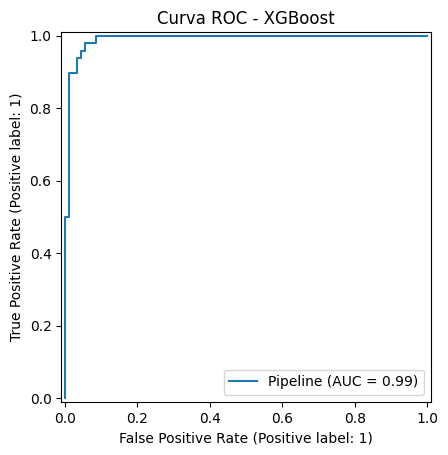

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(xgb_pipe, X_test, y_test_bin)
plt.title("Curva ROC - XGBoost")
plt.show()

Buena generalización (accuracy 0.95).

Detecta muy bien malignos (recall 0.94).

Balance sólido (F1 0.93).

Separación casi perfecta (AUC 0.99).

La curva está pegada al eje superior izquierdo.

El AUC de 0.99 indica excelente capacidad de separación.

Esto significa que, ajustando el umbral, podríamos priorizar recall clínico si fuera necesario.

3. Ajustar parámetros: max_depth, learning_rate, n_estimators.


Optimizar estos hiperparámetros de XGBoost:
* max_depth → complejidad del árbol
* learning_rate → tamaño del paso en cada iteración
* n_estimators → cantidad de árboles

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__n_estimators": [100, 200, 300]
}

grid = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid,
    scoring="roc_auc",      # más robusto que accuracy
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train_bin)

print("Mejores parámetros encontrados:")
print(grid.best_params_)

print("Mejor AUC CV:", grid.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores parámetros encontrados:
{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 200}
Mejor AUC CV: 0.99175106835525


* Un modelo más simple generaliza mejor en este dataset.

4. Evaluar métricas: accuracy, F1, AUC.


In [ ]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("\n=== XGBoost Optimizado ===")
print("Accuracy:", accuracy_score(y_test_bin, y_pred))
print("F1:", f1_score(y_test_bin, y_pred))
print("AUC:", roc_auc_score(y_test_bin, y_prob))


=== XGBoost Optimizado ===
Accuracy: 0.9571428571428572
F1: 0.9375
AUC: 0.9912817028985508


* El tuning confirmó que no necesitamos árboles profundos.
Con max_depth = 2 el modelo logra una excelente capacidad de separación sin sobreajustar.

5. Repetir con CatBoostClassifier.


In [ ]:
!pip -q install catboost

In [ ]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.metrics import RocCurveDisplay
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

In [ ]:
y_train_bin = (y_train.values.ravel() == 4).astype(int)
y_test_bin  = (y_test.values.ravel()  == 4).astype(int)

In [ ]:
cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), # opcional
    ("model", CatBoostClassifier(
        iterations=300,
        learning_rate=0.1,
        depth=4,
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=0,
        random_seed=42
    ))
])

In [ ]:
cat_pipe.fit(X_train, y_train_bin)

y_pred = cat_pipe.predict(X_test)
y_proba = cat_pipe.predict_proba(X_test)[:, 1]

print("\n=== CatBoostClassifier ===")
print("Accuracy:", accuracy_score(y_test_bin, y_pred))
print("F1 (maligno=1):", f1_score(y_test_bin, y_pred))
print("AUC:", roc_auc_score(y_test_bin, y_proba))

print("\nMatriz de confusión:\n", confusion_matrix(y_test_bin, y_pred))
print("\nClassification report:\n", classification_report(y_test_bin, y_pred, target_names=["Benigno", "Maligno"]))


=== CatBoostClassifier ===
Accuracy: 0.95
F1 (maligno=1): 0.9278350515463918
AUC: 0.9911684782608695

Matriz de confusión:
 [[88  4]
 [ 3 45]]

Classification report:
               precision    recall  f1-score   support

     Benigno       0.97      0.96      0.96        92
     Maligno       0.92      0.94      0.93        48

    accuracy                           0.95       140
   macro avg       0.94      0.95      0.94       140
weighted avg       0.95      0.95      0.95       140



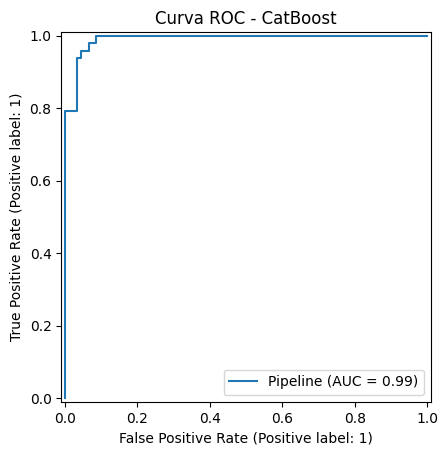

In [ ]:
RocCurveDisplay.from_estimator(cat_pipe, X_test, y_test_bin)
plt.title("Curva ROC - CatBoost")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "model__iterations": [200, 300, 500],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__depth": [2, 3, 4, 5]
}

grid = GridSearchCV(
    cat_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train_bin)

print("Mejores parámetros:", grid.best_params_)
print("Mejor AUC CV:", grid.best_score_)
best_cat = grid.best_estimator_

Mejores parámetros: {'model__depth': 2, 'model__iterations': 200, 'model__learning_rate': 0.05}
Mejor AUC CV: 0.9933643809635159


In [ ]:
y_pred = best_cat.predict(X_test)
y_proba = best_cat.predict_proba(X_test)[:, 1]

print("\n=== CatBoost Optimizado ===")
print("Accuracy:", accuracy_score(y_test_bin, y_pred))
print("F1:", f1_score(y_test_bin, y_pred))
print("AUC:", roc_auc_score(y_test_bin, y_proba))


=== CatBoost Optimizado ===
Accuracy: 0.95
F1: 0.9263157894736842
AUC: 0.9941123188405797


CatBoost te dio prácticamente lo mismo que XGBoost en este dataset.


Cuando el dataset es numérico y relativamente limpio, varios algoritmos de boosting convergen a rendimientos muy parecidos.

CatBoost y XGBoost logran un AUC cercano a 0.99, lo que indica una separación excelente entre benignos y malignos.

En este dataset numérico, la diferencia práctica entre ambos modelos es mínima.

6. Visualizar importancia de variables.


Top 10 variables:
                        feature  importance
5                  Bare_nuclei   27.020992
1      Uniformity_of_cell_size   14.257847
0              Clump_thickness   13.383324
7              Normal_nucleoli   10.912576
2     Uniformity_of_cell_shape   10.637297
6              Bland_chromatin    7.948399
3            Marginal_adhesion    7.017552
4  Single_epithelial_cell_size    4.609036
8                      Mitoses    4.212977


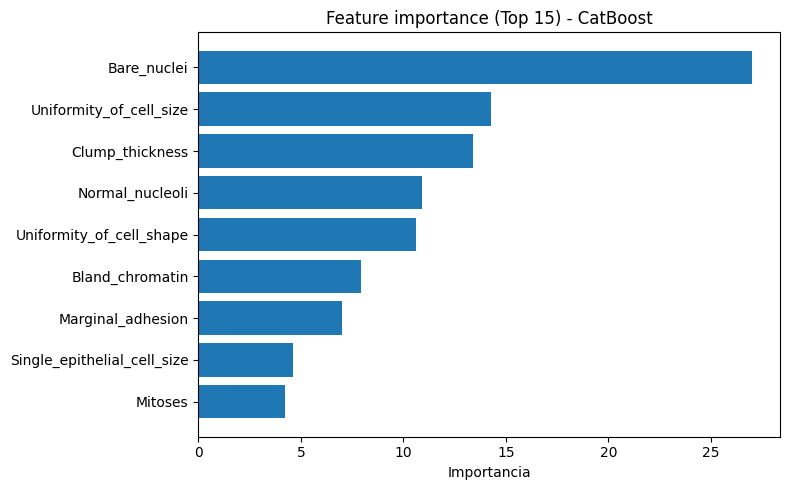

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) sacar el modelo desde el pipeline
cat_model = cat_pipe.named_steps["model"]  # si estás usando best_cat, cambia cat_pipe por best_cat

# 2) obtener importancias
importances = cat_model.get_feature_importance()  # default: PredictionValuesChange

imp_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Top 10 variables:\n", imp_df.head(10))

# 3) gráfico
plt.figure(figsize=(8,5))
top = imp_df.head(15)[::-1]
plt.barh(top["feature"], top["importance"])
plt.title("Feature importance (Top 15) - CatBoost")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

El modelo está priorizando variables relacionadas con estructura y uniformidad celular, que clínicamente tienen sentido en la diferenciación benigno/maligno.

7. Aplicar SHAP para explicación local y global.


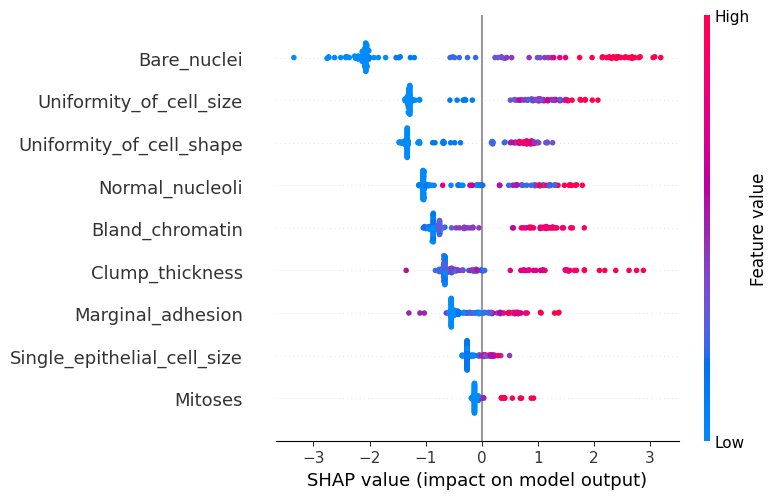

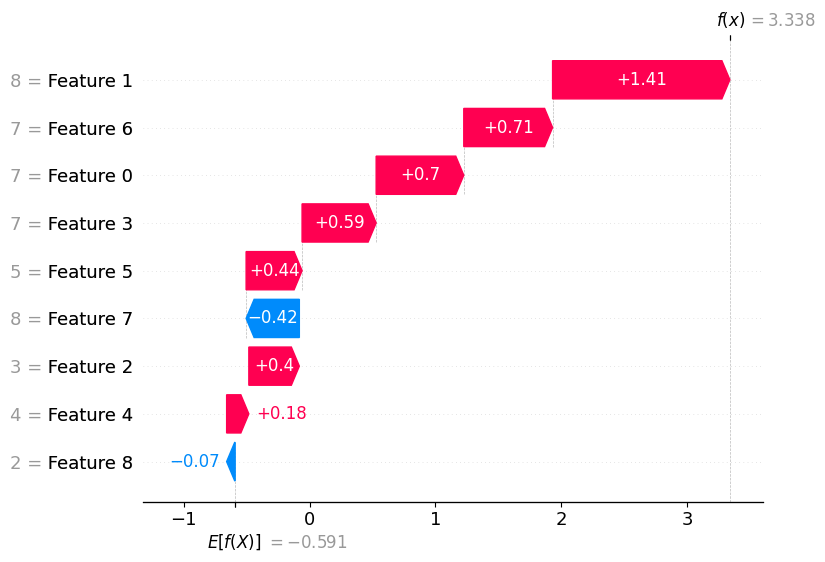

Predicción del modelo (0=benigno, 1=maligno): 1
Probabilidad de maligno: 0.9657025337219238


In [ ]:
# Si no lo tienes instalado:
# !pip -q install shap

import shap
import numpy as np
import matplotlib.pyplot as plt

# 1) Sacar partes del pipeline ya entrenado
imputer = xgb_pipe.named_steps["imputer"]
model   = xgb_pipe.named_steps["model"]

# 2) Transformar datos (importante: SHAP ve lo que ve el modelo)
X_train_imp = imputer.transform(X_train)
X_test_imp  = imputer.transform(X_test)

# Mantener nombres de variables
feature_names = X_train.columns

# 3) Explainer para modelos de árboles
explainer = shap.TreeExplainer(model)

# Para clasificación binaria, shap_values puede devolver:
# - una matriz (n_samples, n_features)  o
# - una lista [clase0, clase1]
shap_values = explainer.shap_values(X_test_imp)

# Normalizamos para quedarnos con la clase positiva (maligno=1)
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]   # clase 1 = maligno
else:
    shap_values_pos = shap_values

# ====== GLOBAL: resumen (beeswarm) ======
shap.summary_plot(
    shap_values_pos,
    X_test_imp,
    feature_names=feature_names,
    show=True
)

# ====== LOCAL: explicar un caso específico ======
i = 0  # cambia el índice para mirar otra fila
x_i = X_test_imp[i]

# waterfall moderno (SHAP >= 0.40 suele usar Explanation)
try:
    exp = explainer(X_test_imp)  # devuelve shap.Explanation
    shap.plots.waterfall(exp[i], max_display=10)
except Exception:
    # fallback compatible con versiones antiguas
    base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_pos[i],
            base_values=base_value,
            data=x_i,
            feature_names=feature_names
        ),
        max_display=10
    )

print("Predicción del modelo (0=benigno, 1=maligno):", int(model.predict([x_i])[0]))
print("Probabilidad de maligno:", float(model.predict_proba([x_i])[0,1]))

Bare_nuclei es la variable dominante.

Valores altos (rojo) empujan fuertemente hacia maligno (SHAP positivo).

Valores bajos (azul) empujan hacia benigno (SHAP negativo).

El modelo parte de un riesgo promedio.

Luego cada característica del paciente mueve la predicción hacia benigno o maligno.

En este caso, múltiples características celulares elevadas empujan fuertemente hacia malignidad.

8. Comparar rendimiento y tiempos.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

# CV (la misma para todos)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scorer F1 para clase positiva = maligno (1)
f1_scorer = make_scorer(f1_score, pos_label=1, average="binary")

scoring = {
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
    "f1": f1_scorer
}

def eval_model(name, model, X, y_bin, cv):
    out = cross_validate(
        model,
        X,
        y_bin,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    return {
        "modelo": name,
        "ACC_mean": np.mean(out["test_accuracy"]),
        "ACC_std": np.std(out["test_accuracy"]),
        "F1_mean": np.mean(out["test_f1"]),
        "F1_std": np.std(out["test_f1"]),
        "AUC_mean": np.mean(out["test_roc_auc"]),
        "AUC_std": np.std(out["test_roc_auc"]),
        "fit_time_mean(s)": np.mean(out["fit_time"]),
        "fit_time_std(s)": np.std(out["fit_time"]),
        "score_time_mean(s)": np.mean(out["score_time"]),
        "score_time_std(s)": np.std(out["score_time"])
    }

# y_bin debe ser 0/1 (0=benigno, 1=maligno)
# Define y_bin for the full dataset X
y_bin = (y.values.ravel() == 4).astype(int) # Convert original labels 2, 4 to 0, 1

results = []
results.append(eval_model("GradientBoosting", best_gb, X, y_bin, cv))
results.append(eval_model("XGBoost (pipe)", xgb_pipe, X, y_bin, cv))
results.append(eval_model("CatBoost", cat_model, X, y_bin, cv))

df_compare = pd.DataFrame(results).sort_values("AUC_mean", ascending=False)
df_compare

,modelo,ACC_mean,ACC_std,F1_mean,F1_std,AUC_mean,AUC_std,fit_time_mean(s),fit_time_std(s),score_time_mean(s),score_time_std(s)
2,CatBoost,0.967102,0.005684,0.952095,0.008888,0.993206,0.003421,0.636530,0.184928,0.029174,0.013266
1,XGBoost (pipe),0.961377,0.007265,0.943749,0.011344,0.991528,0.005720,0.092902,0.021457,0.023933,0.003882
0,GradientBoosting,0.959908,0.015533,0.941522,0.022732,0.990551,0.003475,0.386852,0.043222,0.020443,0.002228


**Conclusiones (rendimiento + tiempos)**

* Mejor rendimiento global: CatBoost
  - Tiene los mejores promedios en las 3 métricas: Accuracy = 0.967, F1 = 0.952, AUC = 0.993.
  - Además es estable (desviaciones bajas: ACC_std ~0.0057, F1_std ~0.0089, AUC_std ~0.0034).

* Segundo lugar: XGBoost (pipe)
  - Muy buen desempeño, pero un poco por debajo de CatBoost: ACC = 0.961, F1 = 0.944, AUC = 0.992.
  - También es estable (std relativamente baja).

* GradientBoosting queda tercero
  - Métricas levemente más bajas: ACC = 0.960, F1 = 0.942, AUC = 0.991.
  - Y es el más variable en F1 (F1_std ~0.0227), o sea, su desempeño cambia más entre folds.

**Conclusiones de tiempos**

* Más rápido entrenando: XGBoost
  - fit_time_mean ~ 0.062 s, muy por debajo de CatBoost (~ 0.439 s) y GradientBoosting (~0.370 s).
  - Si tu foco es iterar rápido (muchas pruebas), XGB te da velocidad.

* Más rápido prediciendo: CatBoost
  - score_time_mean ~0.013 s, el menor de los tres.
  - En escenarios de “muchas predicciones” (producción), esto suma.

Si quiero máxima calidad predictiva (y consistencia): CatBoost.

Si quiero buen rendimiento pero entrenar ultra rápido para probar cosas: XGBoost.

Si quiero un baseline clásico y simple (pero menos estable en F1): GradientBoosting.